In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Loading processed data
train_df = pd.read_csv('data/processed/train.csv')
val_df   = pd.read_csv('data/processed/val.csv')
test_df  = pd.read_csv('data/processed/test.csv')

feat_cols = [f'f{i}' for i in range(1, 137)]

print(f'Train : {len(train_df):,} rows | {train_df["qid"].nunique():,} queries')
print(f'Val   : {len(val_df):,} rows | {val_df["qid"].nunique():,} queries')
print(f'Test  : {len(test_df):,} rows | {test_df["qid"].nunique():,} queries')

Train : 723,412 rows | 6,000 queries
Val   : 235,259 rows | 2,000 queries
Test  : 241,521 rows | 2,000 queries


### Label Distribution

> **Why this matters:** Class imbalance affects how models learn and how we evaluate them.
> If 52% of documents are label=0 (from setup notebook), a model that always predicts 0 gets 52% accuracy — but is useless for ranking.
> This is why we use ranking metrics (NDCG, MAP) instead of accuracy.

In [25]:
label_counts = train_df['label'].value_counts().sort_index()
label_pct    = label_counts / label_counts.sum() * 100

label_names = {
    0: 'Irrelevant',
    1: 'Slightly Relevant',
    2: 'Fairly Relevant',
    3: 'Highly Relevant',
    4: 'Perfectly Relevant'
}
for label, count in label_counts.items():
    bar = '|' * int(label_pct[label])
    print(f'Label {label} ({label_names[label]:<20}): {count:>7,}  {label_pct[label]:>5.1f}%  {bar}')

print(f'\nTotal documents: {label_counts.sum():,}')
print(f'Relevant docs (label >= 1): {(train_df["label"] >= 1).sum():,} ({(train_df["label"] >= 1).mean()*100:.1f}%)')
print(f'Highly relevant (label >= 3): {(train_df["label"] >= 3).sum():,} ({(train_df["label"] >= 3).mean()*100:.1f}%)')

Label 0 (Irrelevant          ): 377,957   52.2%  ||||||||||||||||||||||||||||||||||||||||||||||||||||
Label 1 (Slightly Relevant   ): 232,569   32.1%  ||||||||||||||||||||||||||||||||
Label 2 (Fairly Relevant     ):  95,082   13.1%  |||||||||||||
Label 3 (Highly Relevant     ):  12,658    1.7%  |
Label 4 (Perfectly Relevant  ):   5,146    0.7%  

Total documents: 723,412
Relevant docs (label >= 1): 345,455 (47.8%)
Highly relevant (label >= 3): 17,804 (2.5%)


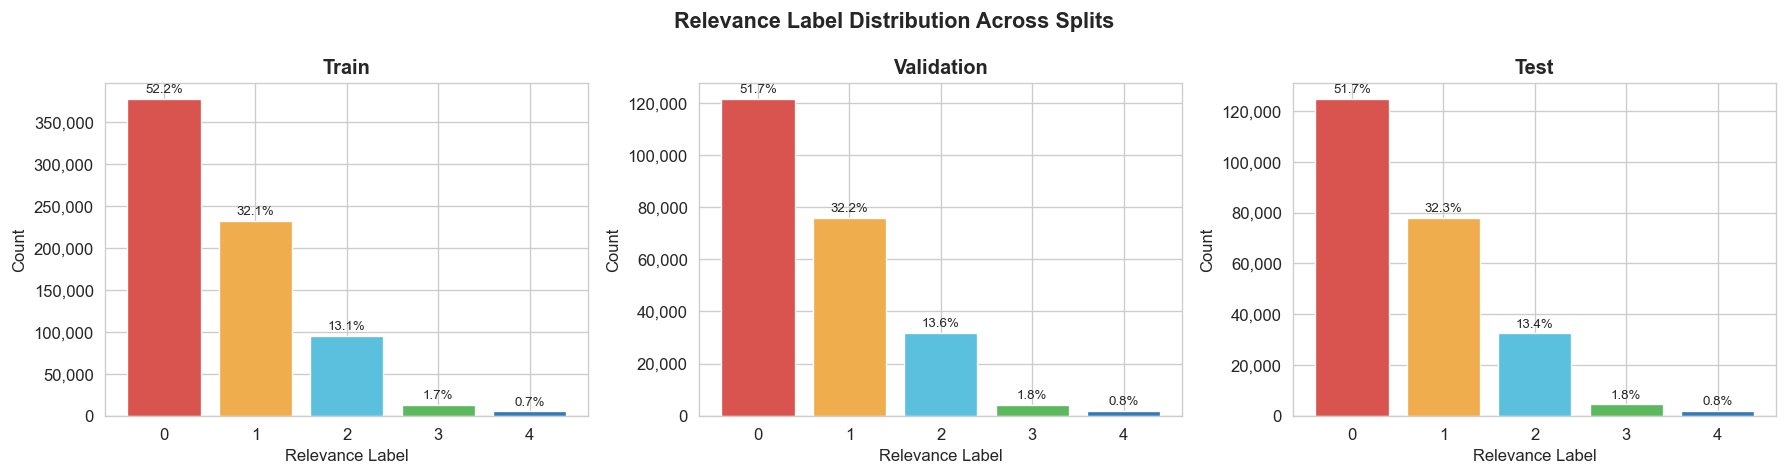


key insight: label=0 dominates (~52%). This is realistic for web search.
Using NDCG/MAP for evaluation — accuracy is not useful here.


In [26]:
# Visualizing label imbalance across all splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Relevance Label Distribution Across Splits', fontsize=13, fontweight='bold')

palette = ['#D9534F', '#F0AD4E', '#5BC0DE', '#5CB85C', '#337AB7']

for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values,
                  color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Relevance Label')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total * 0.005,
                f'{val/total*100:.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plots/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nkey insight: label=0 dominates (~52%). This is realistic for web search.')
print('Using NDCG/MAP for evaluation — accuracy is not useful here.')

### Query-Level Analysis

> **Why this matters:** Each query is an independent ranking problem.
> Some queries are "easy" (many relevant docs) and some are "hard" (few or none).
> Understanding query difficulty will help in interpreting model performance and designing A/B test segments.

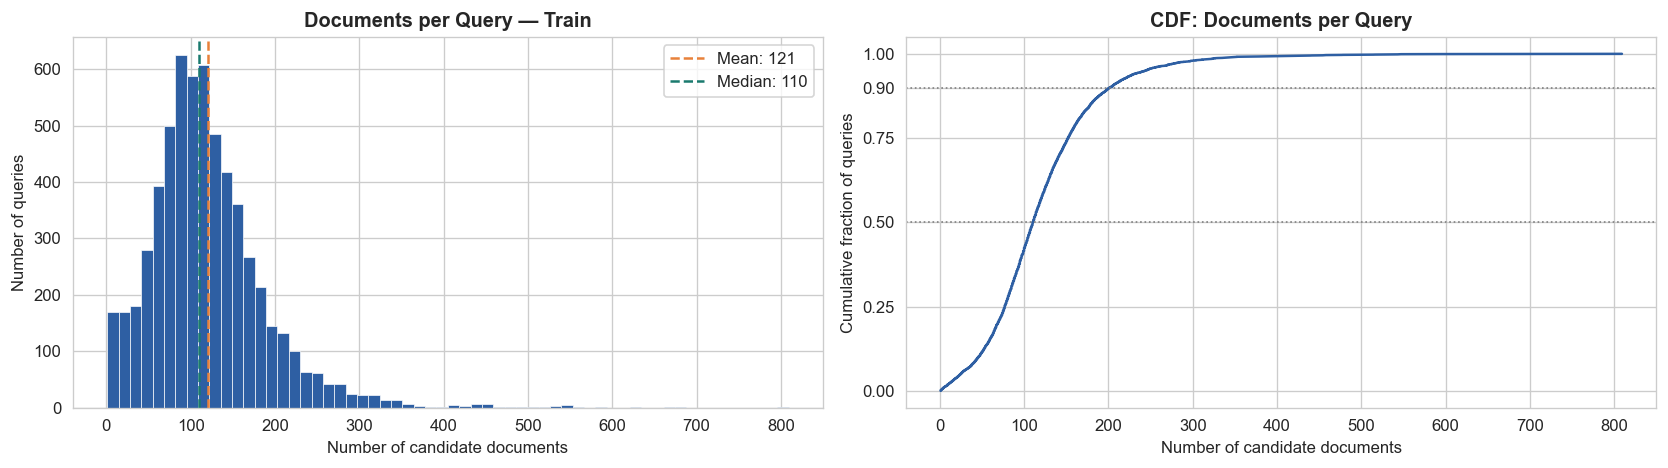

Min docs/query: 1
Max docs/query: 809
Mean: 120.6
Median: 110.0
25th percentile: 77
50th percentile: 110
70th percentile: 142
90th percentile: 202


In [27]:
# Plotting docs per query distribution
docs_per_query = train_df.groupby('qid').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left chart: histogram
axes[0].hist(docs_per_query, bins=60, color='#2E5FA3', edgecolor='white', linewidth=0.4)
axes[0].axvline(docs_per_query.mean(),   color='#E8813A', linestyle='--', lw=1.5,
                label=f'Mean: {docs_per_query.mean():.0f}')
axes[0].axvline(docs_per_query.median(), color='#1A7A6E', linestyle='--', lw=1.5,
                label=f'Median: {docs_per_query.median():.0f}')
axes[0].set_title('Documents per Query — Train', fontweight='bold')
axes[0].set_xlabel('Number of candidate documents')
axes[0].set_ylabel('Number of queries')
axes[0].legend()

# Right chart: cumulative distribution
sorted_docs = np.sort(docs_per_query)
cdf = np.arange(1, len(sorted_docs)+1) / len(sorted_docs)
axes[1].plot(sorted_docs, cdf, color='#2E5FA3', lw=1.5)
axes[1].axhline(0.5, color='gray', linestyle=':', lw=1)
axes[1].axhline(0.9, color='gray', linestyle=':', lw=1)
axes[1].set_title('CDF: Documents per Query', fontweight='bold')
axes[1].set_xlabel('Number of candidate documents')
axes[1].set_ylabel('Cumulative fraction of queries')
axes[1].set_yticks([0, 0.25, 0.5, 0.75, 0.9, 1.0])

plt.tight_layout()
plt.savefig('outputs/plots/01_docs_per_query.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min docs/query: {docs_per_query.min()}')
print(f'Max docs/query: {docs_per_query.max()}')
print(f'Mean: {docs_per_query.mean():.1f}')
print(f'Median: {docs_per_query.median():.1f}')
print(f'25th percentile: {docs_per_query.quantile(0.25):.0f}')
print(f'50th percentile: {docs_per_query.quantile(0.5):.0f}')
print(f'70th percentile: {docs_per_query.quantile(0.7):.0f}')
print(f'90th percentile: {docs_per_query.quantile(0.9):.0f}')

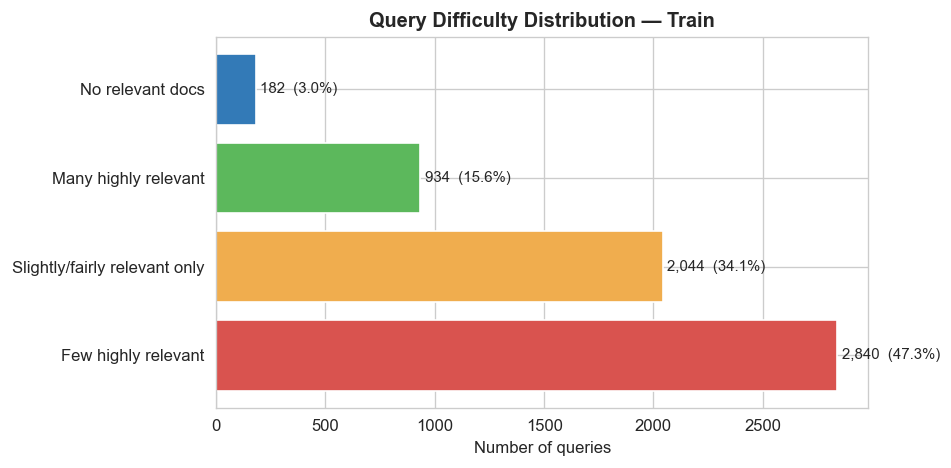


key insight: ~3% of queries have zero relevant documents.
These are impossible to rank correctly — good candidates to flag in A/B testing.


In [28]:
# Query difficulty: what fraction of queries have relevant / highly relevant docs
query_stats = train_df.groupby('qid')['label'].agg(
    max_label='max',
    n_docs='count',
    n_relevant=lambda x: (x >= 1).sum(),
    n_highly_relevant=lambda x: (x >= 3).sum()
)
query_stats['pct_relevant']        = query_stats['n_relevant'] / query_stats['n_docs']
query_stats['pct_highly_relevant'] = query_stats['n_highly_relevant'] / query_stats['n_docs']

# Difficulty buckets
def difficulty_bucket(row):
    if row['max_label'] == 0:
        return 'No relevant docs'
    elif row['n_highly_relevant'] == 0:
        return 'Slightly/fairly relevant only'
    elif row['pct_highly_relevant'] < 0.05:
        return 'Few highly relevant'
    else:
        return 'Many highly relevant'

query_stats['difficulty'] = query_stats.apply(difficulty_bucket, axis=1)
diff_counts = query_stats['difficulty'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#D9534F', '#F0AD4E', '#5CB85C', '#337AB7']
bars = ax.barh(diff_counts.index, diff_counts.values,
               color=colors[:len(diff_counts)], edgecolor='white')
ax.set_title('Query Difficulty Distribution — Train', fontweight='bold')
ax.set_xlabel('Number of queries')
for bar, val in zip(bars, diff_counts.values):
    pct = val / diff_counts.sum() * 100
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plots/01_query_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nkey insight: ~3% of queries have zero relevant documents.')
print('These are impossible to rank correctly — good candidates to flag in A/B testing.')

### Analyzing Feature Distributions

> **Why this matters:** Feature scale and distribution affect model training.
> Large value ranges (we saw -2B to +980M) suggest normalisation is needed.
> Skewed distributions are common in TF/BM25 features (most documents have low scores, a few have very high).

In [29]:
# Feature value range statistics
feat_stats = train_df[feat_cols].describe().T
feat_stats['range'] = feat_stats['max'] - feat_stats['min']
feat_stats['cv']    = feat_stats['std'] / (feat_stats['mean'].abs() + 1e-9)  # coefficient of variation

print('Top 10 features by value range (widest scale):')
print(feat_stats.nlargest(10, 'range')[['min', 'max', 'range', 'mean', 'std']].to_string())

print('\nTop 10 features by coefficient of variation (most variable relative to mean):')
print(feat_stats.nlargest(10, 'cv')[['mean', 'std', 'cv']].to_string())

Top 10 features by value range (widest scale):
               min           max         range          mean           std
f128 -2.083778e+09  3.141316e+08  2.397910e+09  87953.880596  7.517011e+06
f136  0.000000e+00  9.800000e+08  9.800000e+08  18243.430242  3.456017e+06
f95   0.000000e+00  1.675053e+08  1.675053e+08   2328.861338  2.033052e+05
f91   0.000000e+00  1.668048e+08  1.668048e+08   2119.032595  2.013899e+05
f134  0.000000e+00  1.315019e+07  1.315019e+07    207.497586  2.830124e+04
f93   0.000000e+00  1.034302e+07  1.034302e+07     66.679771  1.369291e+04
f135  0.000000e+00  2.789632e+06  2.789632e+06    459.356690  1.939316e+04
f45   0.000000e+00  2.783892e+06  2.783892e+06    112.046934  3.756556e+03
f41   0.000000e+00  2.763906e+06  2.763906e+06    102.604495  3.618201e+03
f71  -1.388741e+03  3.685574e+05  3.699461e+05     83.318809  9.652155e+02

Top 10 features by coefficient of variation (most variable relative to mean):
              mean           std          cv
f93 

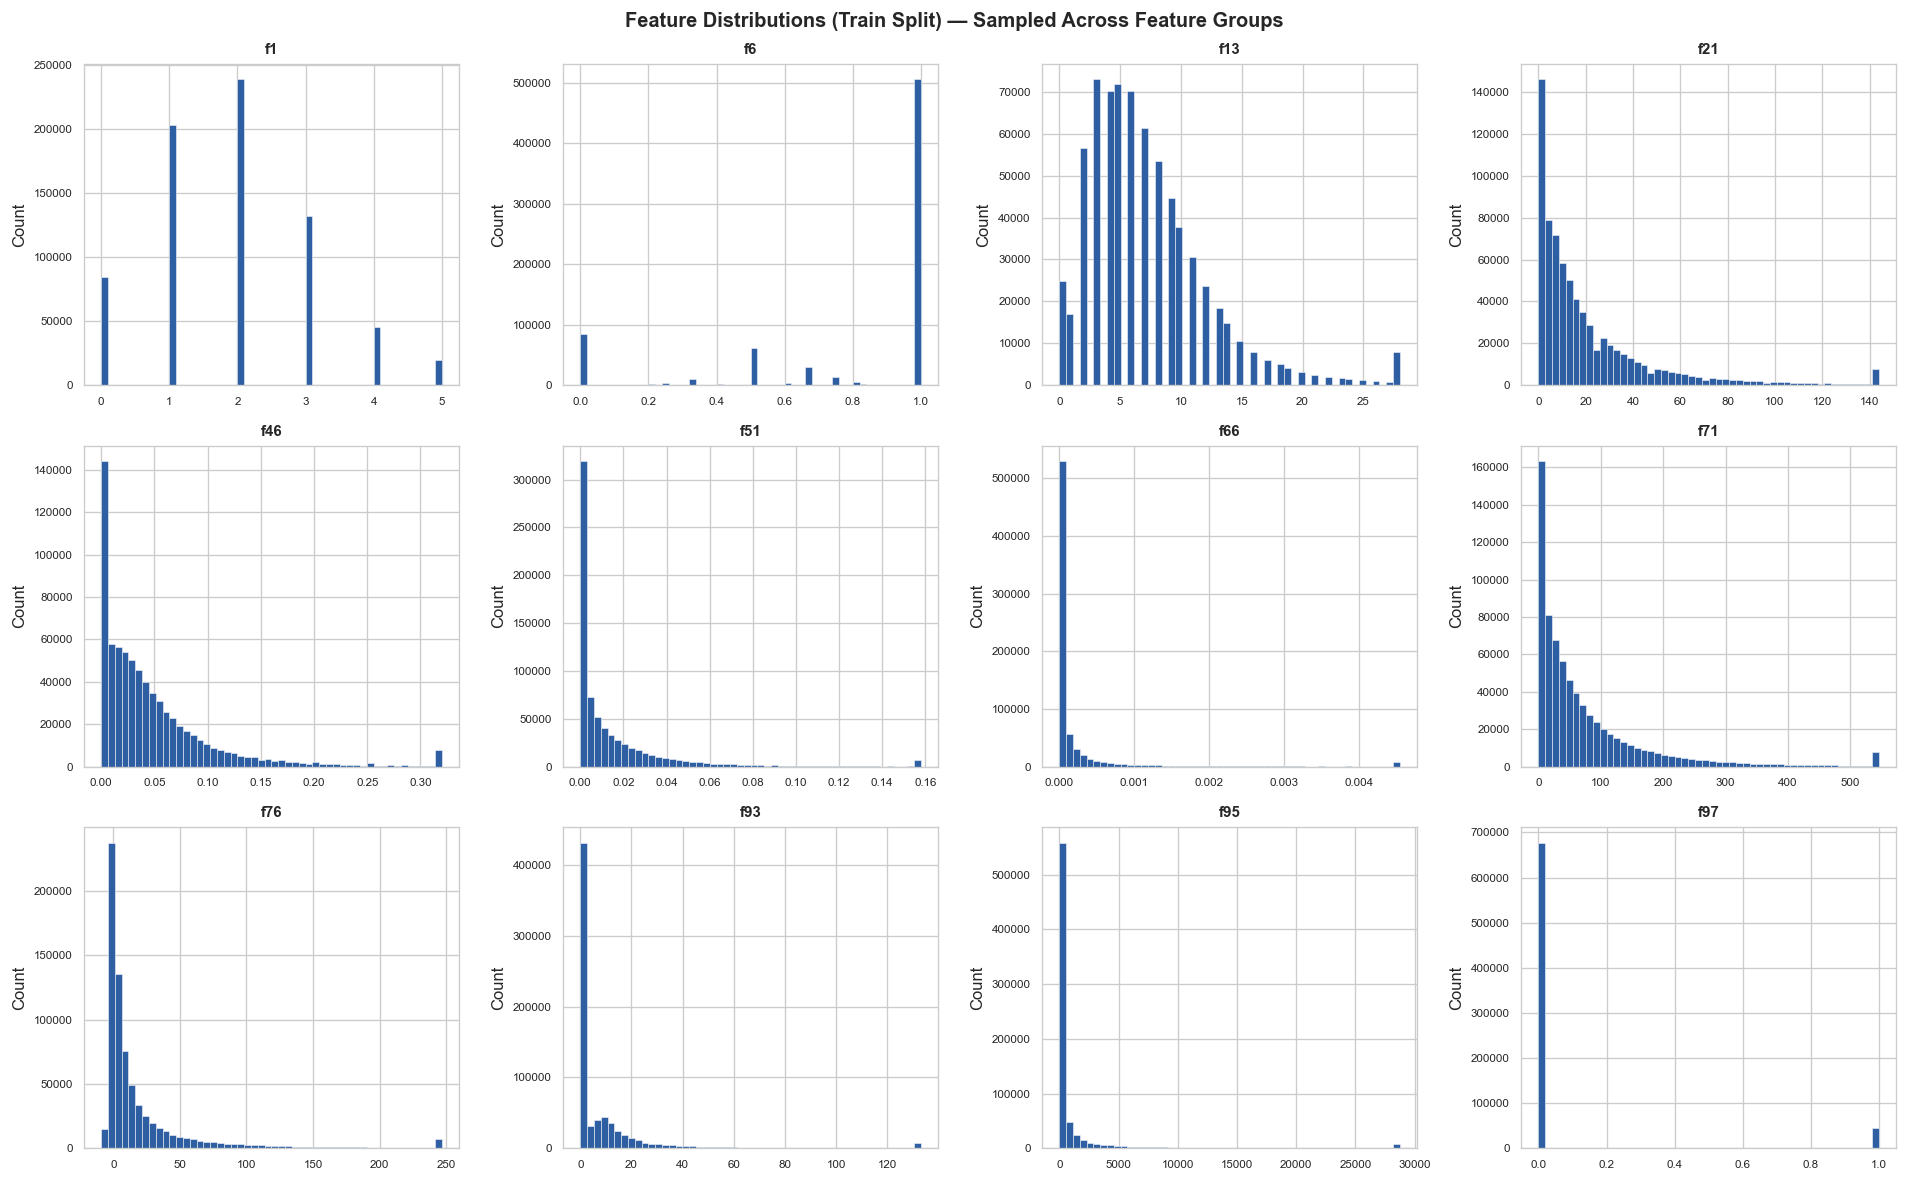

Note: Values clipped to [1st, 99th] percentile for visibility.
Many features are right-skewed — common for TF/BM25 style signals.


In [30]:
# Sampling 20 representative features and showing their distributions
# Chosen to cover different feature families
sample_feats = [
    'f1',   
    'f6',
    'f13',
    'f21',  
    'f46',
    'f51',
    'f66',
    'f71',  
    'f76',  
    'f93',  
    'f95',  
    'f97',  
    'f99',
    'f104',
    'f109', 
    'f114', 
    'f120',
    'f127',
    'f131',
    'f136'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Feature Distributions (Train Split) — Sampled Across Feature Groups',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flatten(), sample_feats):
    data = train_df[feat].clip(
        train_df[feat].quantile(0.01),
        train_df[feat].quantile(0.99)
    )
    ax.hist(data, bins=50, color='#2E5FA3', edgecolor='white', linewidth=0.3)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_ylabel('Count')
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Values clipped to [1st, 99th] percentile for visibility.')
print('Many features are right-skewed — common for TF/BM25 style signals.')

### Skewness Analysis


> Quantifying skewness is important for two reasons:
> - It tells us whether 3σ is appropriate for outlier detection (it isn't for skewed data — IQR is better)
> - It tells us which features may benefit from a log transform in feature engineering
>
> **Skewness interpretation:**
> - |skew| < 0.5 → roughly symmetric
> - 0.5 < |skew| < 1 → moderately skewed
> - |skew| > 1 → highly skewed
> - |skew| > 3 → severely skewed

In [31]:
from scipy.stats import skew

# Computing skewness for all 136 features
skewness = {feat: skew(train_df[feat].dropna()) for feat in feat_cols}
skew_series = pd.Series(skewness).sort_values(ascending=False)

n_high   = (skew_series.abs() > 1).sum()
n_severe = (skew_series.abs() > 3).sum()
n_sym    = (skew_series.abs() < 0.5).sum()

print(f'Roughly symmetric (|skew| < 0.5): {n_sym} features')
print(f'Highly skewed (|skew| > 1): {n_high} features')
print(f'Severely skewed (|skew| > 3): {n_severe} features')
print(f'\nTop 10 most positively skewed features:')
print(skew_series.head(10).to_string())
print(f'\nTop 10 most negatively skewed features:')
print(skew_series.tail(10).to_string())

Roughly symmetric (|skew| < 0.5): 4 features
Highly skewed (|skew| > 1): 124 features
Severely skewed (|skew| > 3): 75 features

Top 10 most positively skewed features:
f91     788.049401
f95     776.353671
f41     632.325608
f93     616.252386
f45     584.986635
f43     545.712276
f92     405.329166
f42     366.497807
f134    350.059214
f21     330.330669

Top 10 most negatively skewed features:
f124     -1.964817
f116     -2.337590
f113     -2.341463
f120     -2.407669
f123     -2.463093
f111     -2.741254
f115     -2.813275
f121     -2.871441
f125     -2.944674
f128   -232.821523


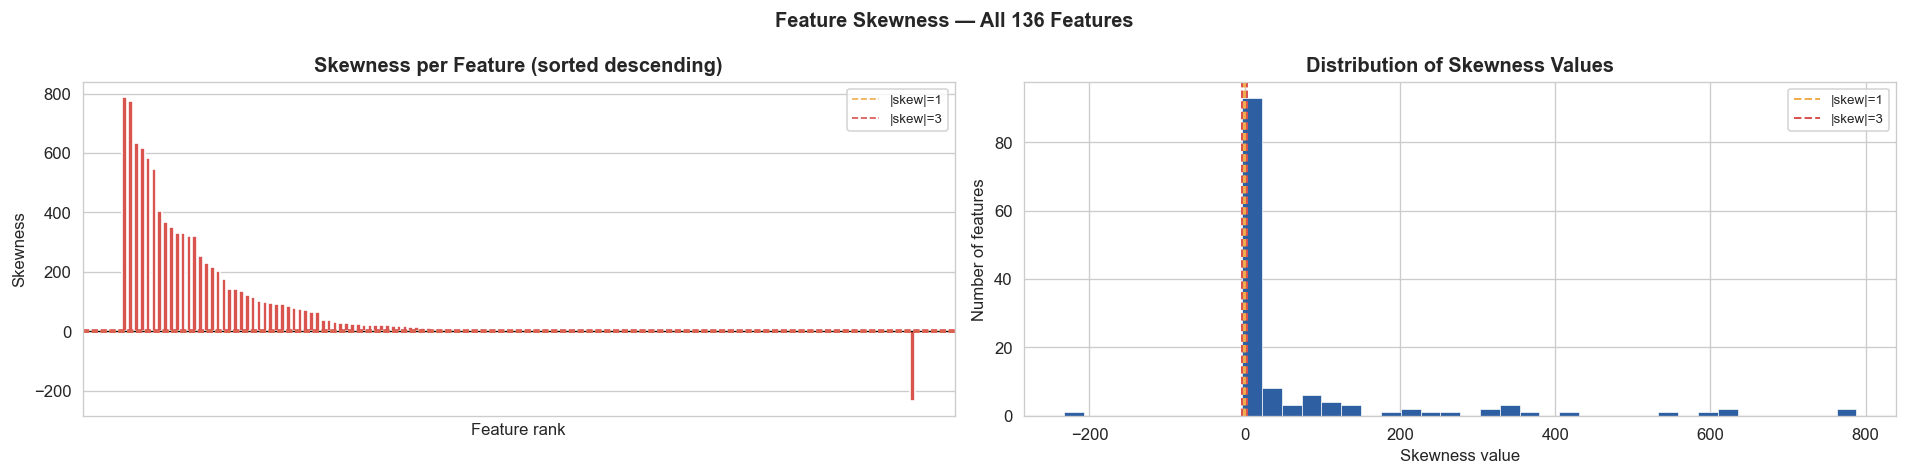

Key insight: 75 features are severely skewed (|skew| > 3).
For skewed features, 3-sigma is unreliable for outlier detection.
The mean and std are both distorted heavily, pushing the threshold too high.
We will use IQR methodnstead — it is rank-based and robust to skew.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Feature Skewness — All 136 Features', fontsize=12, fontweight='bold')

# Left: bar chart of skewness per feature (sorted)
colors_skew = [
    '#D9534F' if abs(v) > 3 else
    '#F0AD4E' if abs(v) > 1 else
    '#2E5FA3'
    for v in skew_series
]
axes[0].bar(range(len(skew_series)), skew_series.values, color=colors_skew, width=0.8)
axes[0].axhline(0,  color='black', lw=0.8)
axes[0].axhline(1,  color='#F0AD4E', lw=1, linestyle='--', label='|skew|=1')
axes[0].axhline(-1, color='#F0AD4E', lw=1, linestyle='--')
axes[0].axhline(3,  color='#D9534F', lw=1, linestyle='--', label='|skew|=3')
axes[0].axhline(-3, color='#D9534F', lw=1, linestyle='--')
axes[0].set_title('Skewness per Feature (sorted descending)', fontweight='bold')
axes[0].set_xlabel('Feature rank')
axes[0].set_ylabel('Skewness')
axes[0].set_xticks([])
axes[0].legend(fontsize=8)

# Right: histogram of skewness values
axes[1].hist(skew_series.values, bins=40, color='#2E5FA3', edgecolor='white', lw=0.4)
axes[1].axvline(1,  color='#F0AD4E', lw=1.2, linestyle='--', label='|skew|=1')
axes[1].axvline(-1, color='#F0AD4E', lw=1.2, linestyle='--')
axes[1].axvline(3,  color='#D9534F', lw=1.2, linestyle='--', label='|skew|=3')
axes[1].axvline(-3, color='#D9534F', lw=1.2, linestyle='--')
axes[1].set_title('Distribution of Skewness Values', fontweight='bold')
axes[1].set_xlabel('Skewness value')
axes[1].set_ylabel('Number of features')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plots/01_feature_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Key insight: {n_severe} features are severely skewed (|skew| > 3).')
print('For skewed features, 3-sigma is unreliable for outlier detection.')
print('The mean and std are both distorted heavily, pushing the threshold too high.')
print('We will use IQR methodnstead — it is rank-based and robust to skew.')

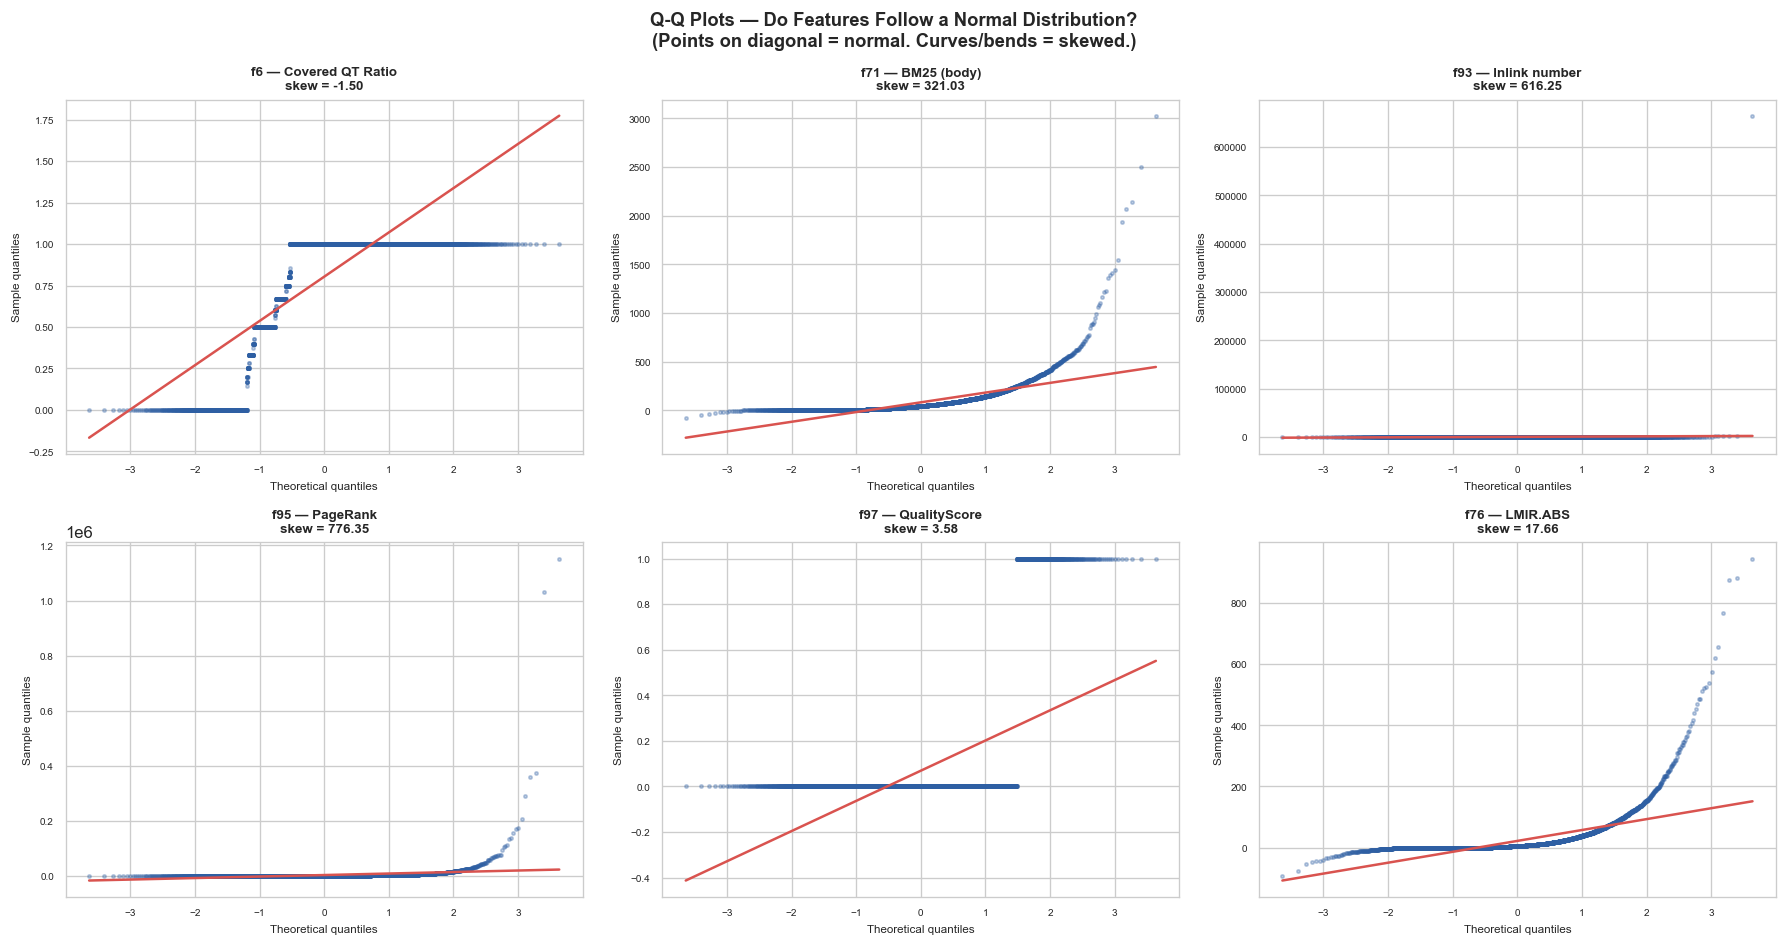

These are poor candidates for 3-sigma outlier detection.


In [33]:
# QQ-plots for 6 representative features: normal vs skewed
# This visually confirms which features deviate from normality
from scipy import stats

qq_feats = [
    ('f6',  'Covered QT Ratio'),
    ('f71', 'BM25 (body)'),
    ('f93', 'Inlink number'),
    ('f95', 'PageRank'),
    ('f97', 'QualityScore'),
    ('f76', 'LMIR.ABS'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Q-Q Plots — Do Features Follow a Normal Distribution?\n'
             '(Points on diagonal = normal. Curves/bends = skewed.)',
             fontsize=11, fontweight='bold')

for ax, (feat, name) in zip(axes.flatten(), qq_feats):
    sample_vals = train_df[feat].dropna().sample(5000, random_state=42)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample_vals, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=4, color='#2E5FA3')
    ax.plot([osm[0], osm[-1]],
            [slope*osm[0]+intercept, slope*osm[-1]+intercept],
            color='#D9534F', lw=1.5, label='Normal line')
    sk = skew_series[feat]
    ax.set_title(f'{feat} — {name}\nskew = {sk:.2f}', fontweight='bold', fontsize=8)
    ax.set_xlabel('Theoretical quantiles', fontsize=7)
    ax.set_ylabel('Sample quantiles', fontsize=7)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('outputs/plots/01_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('These are poor candidates for 3-sigma outlier detection.')

### Feature vs Relevance Label

> **Why this matters:** The core question — do higher feature values correspond to higher relevance labels?
> If yes, the feature is a useful signal for ranking.

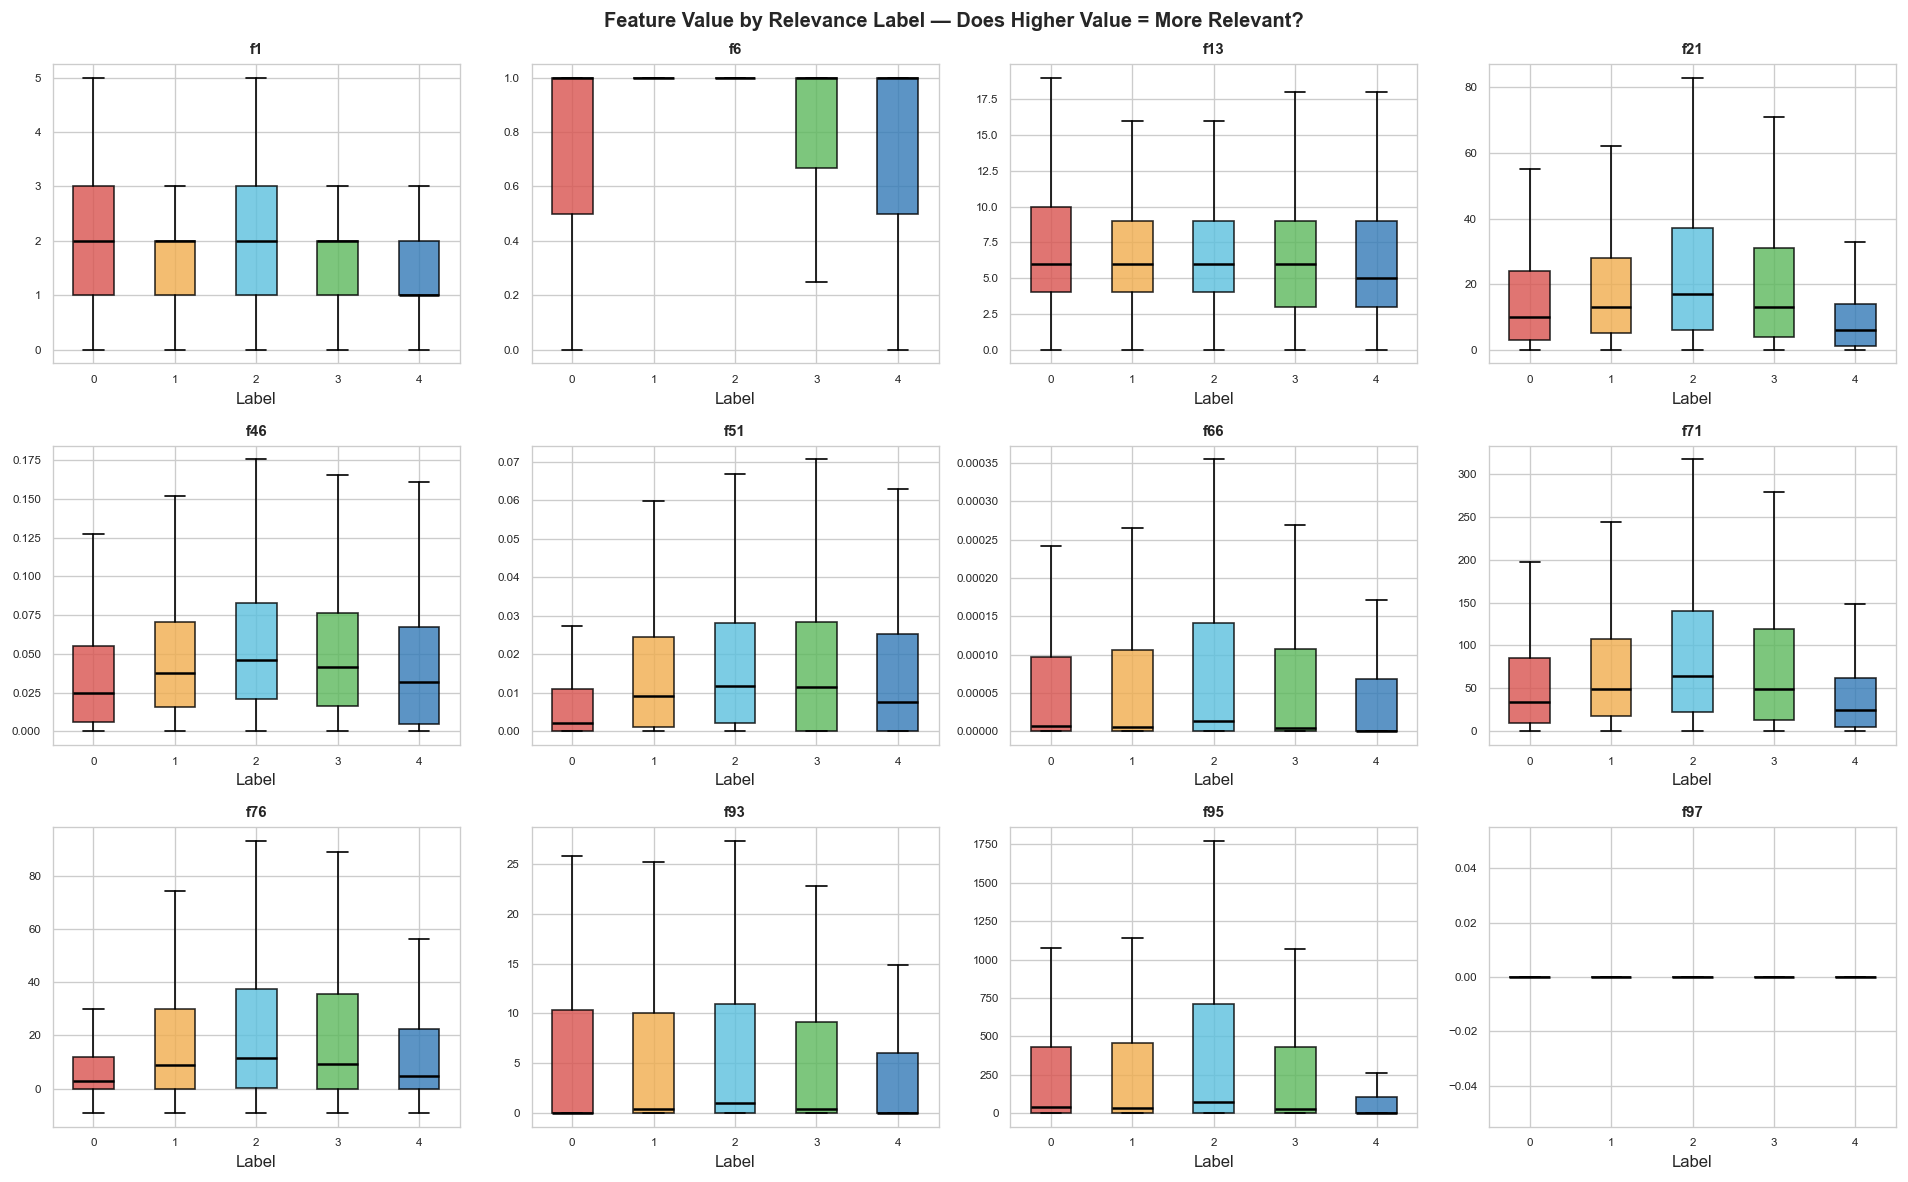

Key insight: BM25 (f71-f75) and TF-IDF features show clear monotonic increase with label.
PageRank (f95), Inlink (f93) show weaker or noisier signal.


In [34]:
# Box plots: feature value distribution by label
# Using the same 12 sample features
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Feature Value by Relevance Label — Does Higher Value = More Relevant?',
             fontsize=12, fontweight='bold')

palette = ['#D9534F', '#F0AD4E', '#5BC0DE', '#5CB85C', '#337AB7']

for ax, feat in zip(axes.flatten(), sample_feats):
    data = train_df[[feat, 'label']].copy()
    data[feat] = data[feat].clip(
        data[feat].quantile(0.01),
        data[feat].quantile(0.99)
    )
    groups = [data.loc[data['label'] == l, feat].values for l in range(5)]
    bp = ax.boxplot(groups, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Label')
    ax.set_xticklabels(range(5))
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/01_feature_vs_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: BM25 (f71-f75) and TF-IDF features show clear monotonic increase with label.')
print('PageRank (f95), Inlink (f93) show weaker or noisier signal.')

### Feature Correlation with Relevance Label

In [35]:
from scipy.stats import spearmanr

# Sampling 50k rows for faster results
sample = train_df.sample(50000, random_state=42)

correlations = {}
for feat in feat_cols:
    corr, _ = spearmanr(sample[feat], sample['label'])
    correlations[feat] = corr

corr_series = pd.Series(correlations).sort_values(ascending=False)

print('\nTop 20 features most positively correlated with relevance:')
print(corr_series.head(20).to_string())

print('\nTop 10 features most negatively correlated with relevance:')
print(corr_series.tail(10).to_string())


Top 20 features most positively correlated with relevance:
f55     0.269811
f30     0.265798
f8      0.263638
f28     0.261453
f98     0.261072
f65     0.260987
f38     0.256019
f53     0.255942
f88     0.255302
f78     0.253405
f51     0.247529
f103    0.247310
f63     0.244631
f26     0.243591
f108    0.237035
f80     0.233234
f61     0.225135
f73     0.223028
f115    0.220010
f76     0.215746

Top 10 features most negatively correlated with relevance:
f41    -0.039232
f14    -0.047401
f126   -0.052157
f20    -0.107906
f16    -0.108268
f11    -0.114627
f15    -0.114736
f19    -0.143425
f17    -0.145776
f18    -0.146065


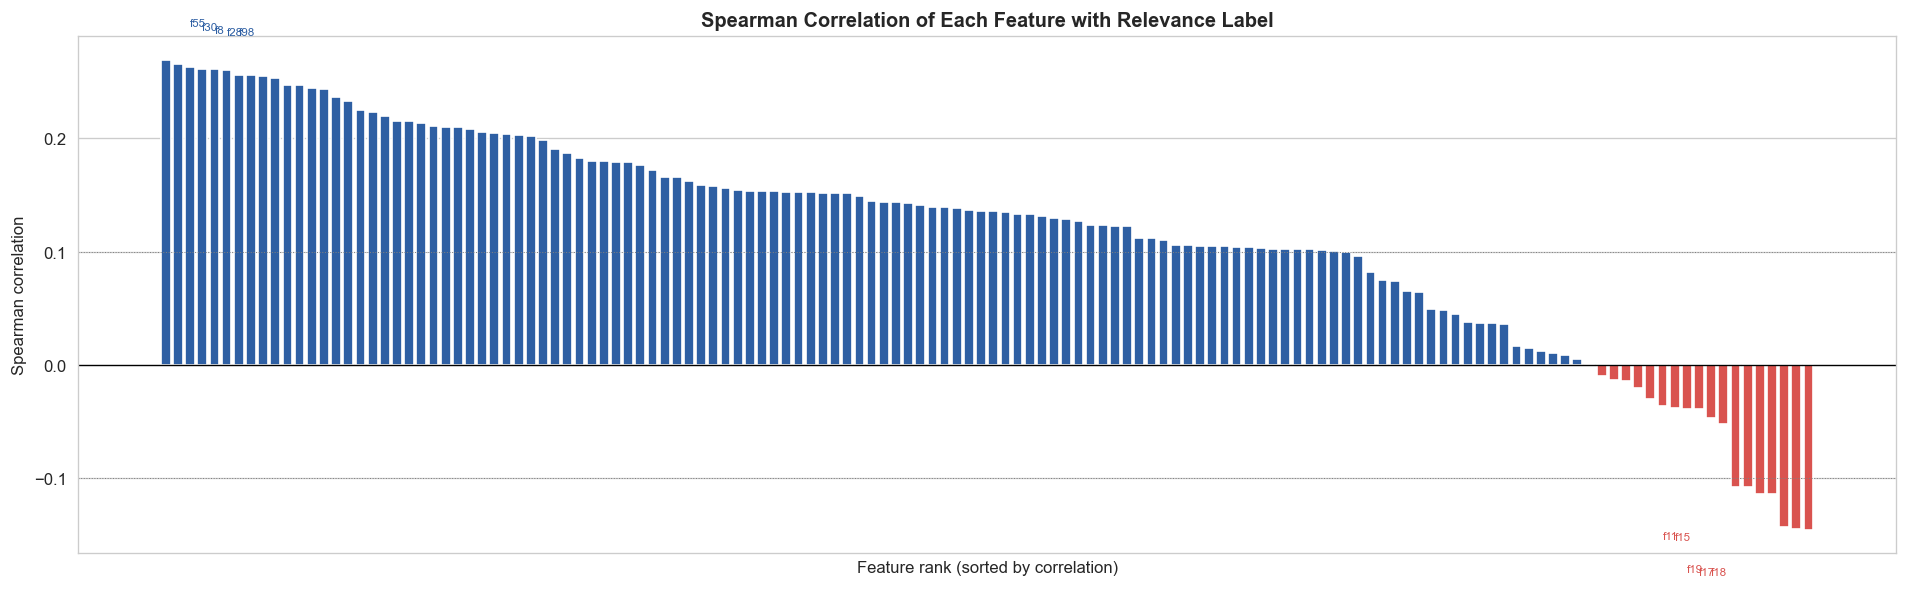

Features with |corr| > 0.10: 104
Features with |corr| > 0.20: 31
Features with |corr| > 0.30: 0


In [36]:
# Visualising all 136 correlations
fig, ax = plt.subplots(figsize=(16, 5))

colors = ['#2E5FA3' if v >= 0 else '#D9534F' for v in corr_series]
ax.bar(range(len(corr_series)), corr_series.values, color=colors, width=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.1,  color='gray', lw=0.6, linestyle=':')
ax.axhline(-0.1, color='gray', lw=0.6, linestyle=':')
ax.set_title('Spearman Correlation of Each Feature with Relevance Label',
             fontweight='bold')
ax.set_xlabel('Feature rank (sorted by correlation)')
ax.set_ylabel('Spearman correlation')
ax.set_xticks([])

# Labeling the top 5 and bottom 5
for i, (feat, val) in enumerate(corr_series.head(5).items()):
    ax.annotate(feat, xy=(i, val), xytext=(i+2, val+0.03),
                fontsize=7, color='#2E5FA3')
for i, (feat, val) in enumerate(corr_series.tail(5).items()):
    idx = len(corr_series) - 5 + i
    ax.annotate(feat, xy=(idx, val), xytext=(idx-8, val-0.04),
                fontsize=7, color='#D9534F')

plt.tight_layout()
plt.savefig('outputs/plots/01_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f'Features with |corr| > 0.10: {(corr_series.abs() > 0.10).sum()}')
print(f'Features with |corr| > 0.20: {(corr_series.abs() > 0.20).sum()}')
print(f'Features with |corr| > 0.30: {(corr_series.abs() > 0.30).sum()}')

### Feature Correlation Heatmap (Top Features)

> **Why this matters:** Highly correlated features carry redundant information.
> Knowing which features cluster together helps us:
> 1. Understand the feature space structure
> 2. Make smarter decisions about feature selection in notebook 02
> 3. Explain why models focus on certain feature groups

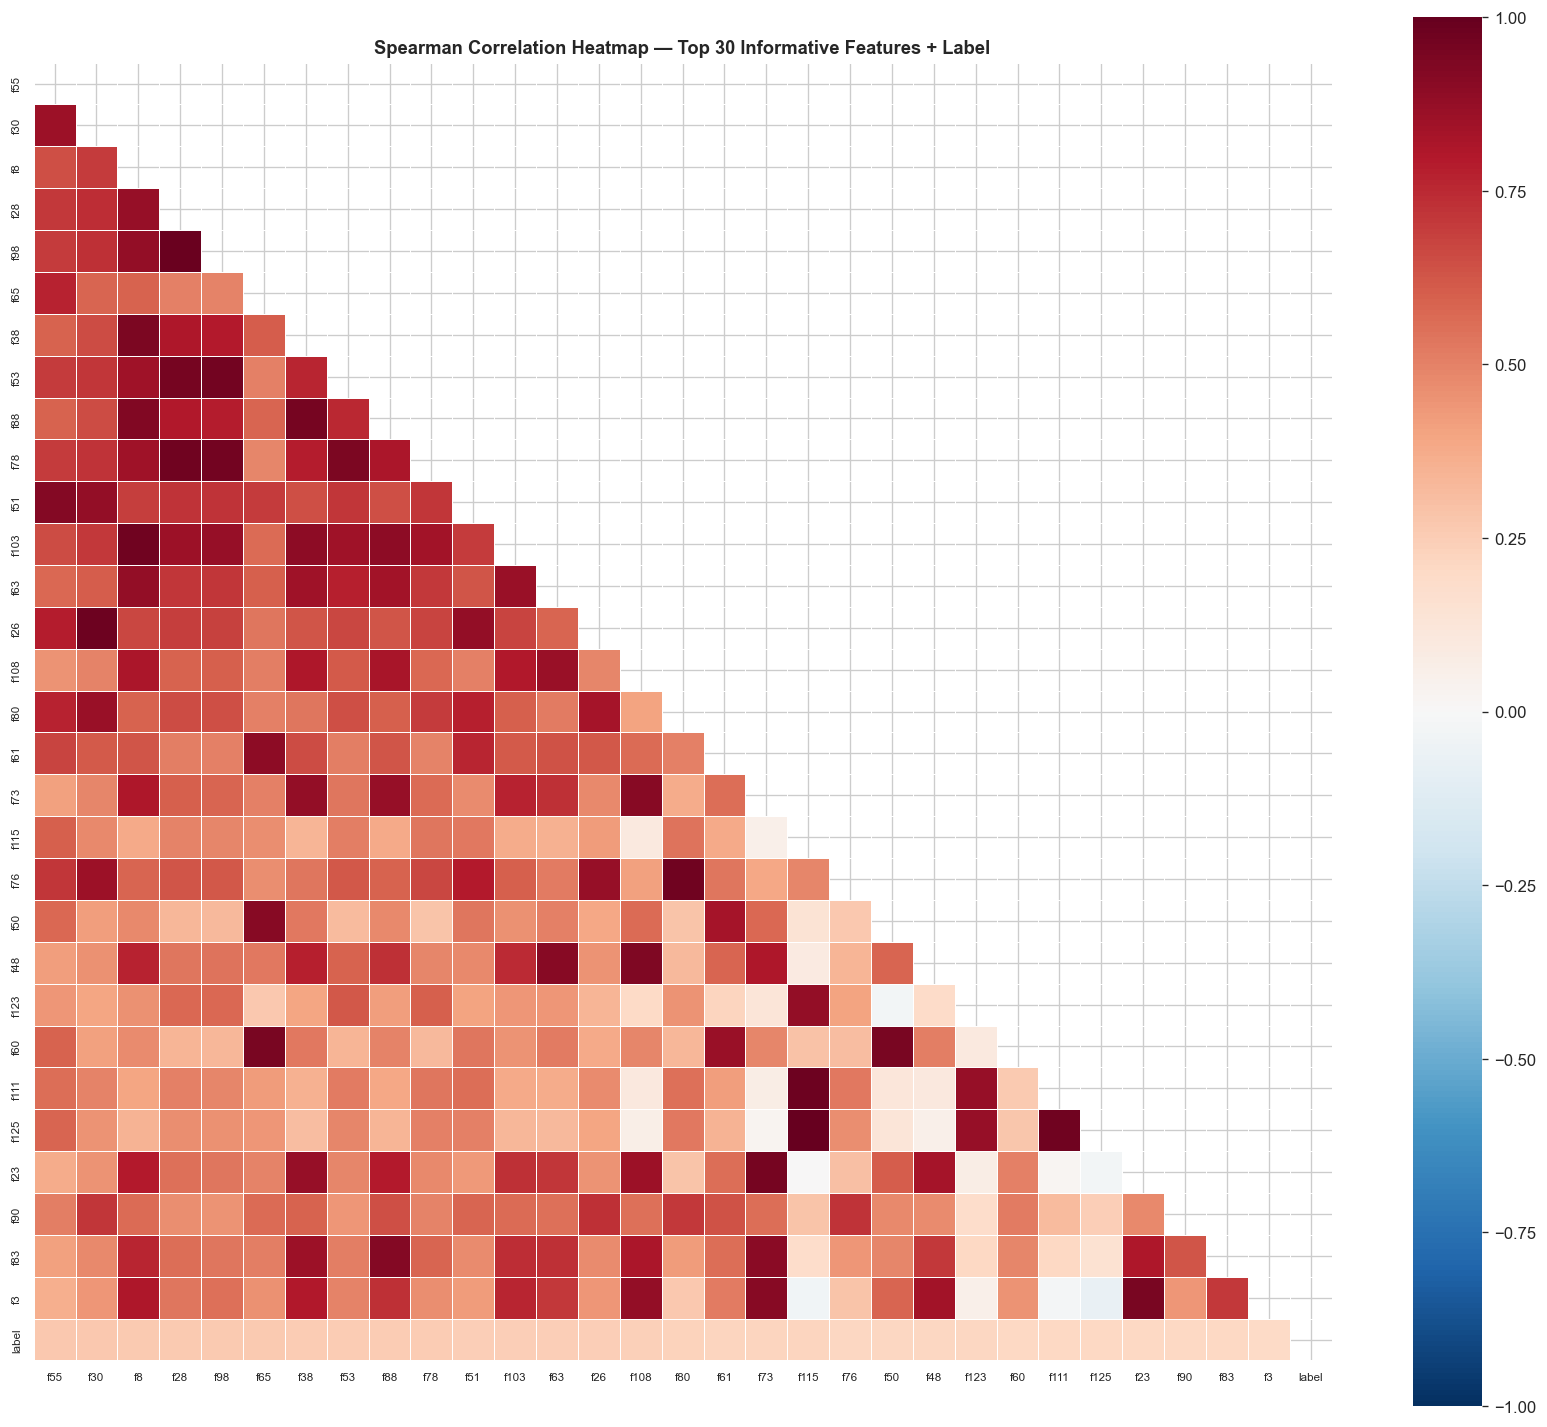

Key insight: TF, TF-IDF, and BM25 features cluster together (highly correlated).
PageRank/quality features are more independent — complementary signal.


In [37]:
# Correlation heatmap for top 30 most informative features
top_feats = corr_series.abs().nlargest(30).index.tolist()

# Adding label column so we can see correlations with target too
heatmap_data = train_df[top_feats + ['label']].sample(50000, random_state=42)
corr_matrix  = heatmap_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot=False,
    ax=ax
)

ax.set_title('Spearman Correlation Heatmap — Top 30 Informative Features + Label',
             fontweight='bold', fontsize=11)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('outputs/plots/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: TF, TF-IDF, and BM25 features cluster together (highly correlated).')
print('PageRank/quality features are more independent — complementary signal.')

### Feature Group Analysis

> **Why this matters:** The 136 features belong to semantic groups (TF, TF-IDF, BM25, etc.).
> Understanding which groups are most predictive guides feature engineering.

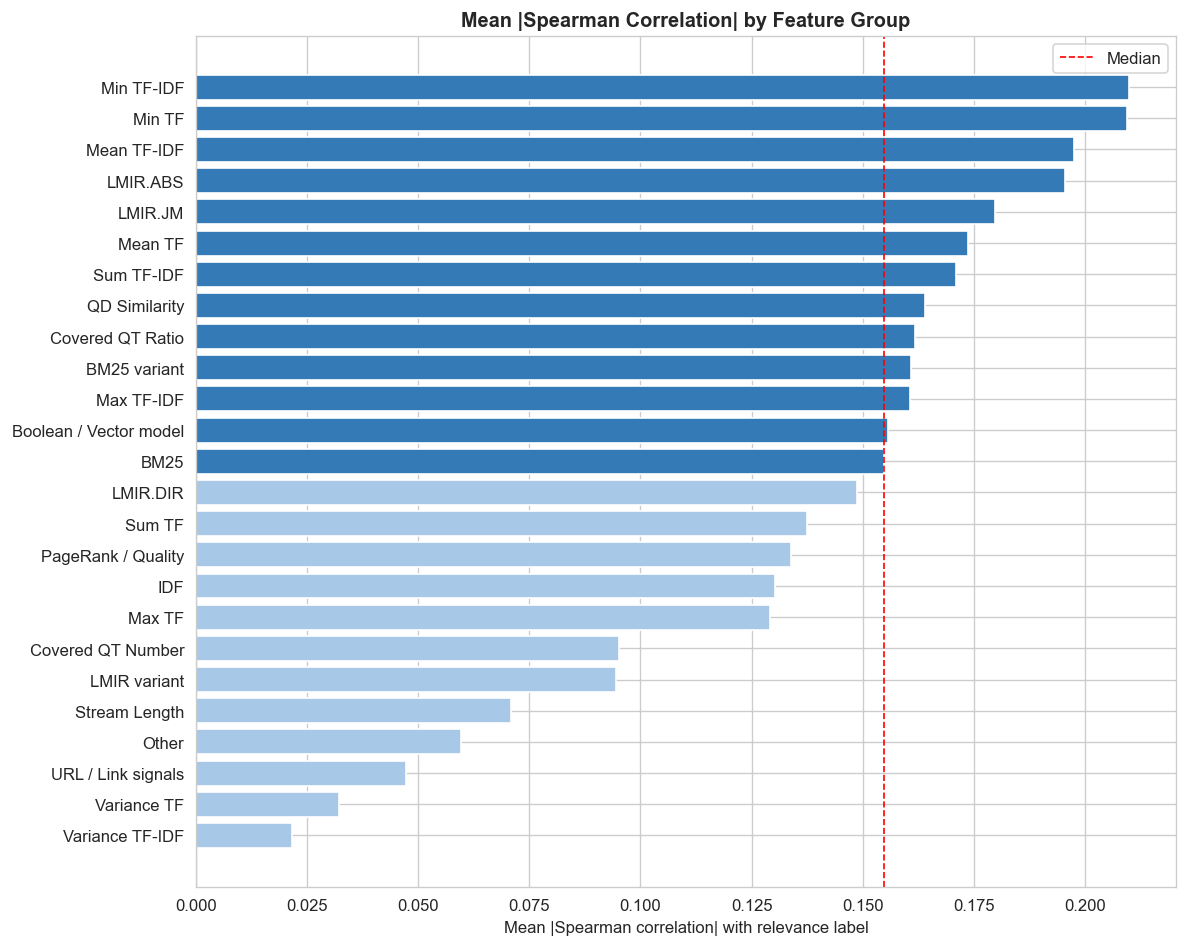

Key insight: TF-IDF and BM25 groups are strongest predictors.
URL/link signals are weaker — but may still contribute to model.


In [38]:
# Average |correlation| per feature group
feature_groups = {
    'Covered QT Number':       [f'f{i}' for i in range(1,  6)],
    'Covered QT Ratio':        [f'f{i}' for i in range(6,  11)],
    'Stream Length':           [f'f{i}' for i in range(11, 16)],
    'IDF':                     [f'f{i}' for i in range(16, 21)],
    'Sum TF':                  [f'f{i}' for i in range(21, 26)],
    'Min TF':                  [f'f{i}' for i in range(26, 31)],
    'Max TF':                  [f'f{i}' for i in range(31, 36)],
    'Mean TF':                 [f'f{i}' for i in range(36, 41)],
    'Variance TF':             [f'f{i}' for i in range(41, 46)],
    'Sum TF-IDF':              [f'f{i}' for i in range(46, 51)],
    'Min TF-IDF':              [f'f{i}' for i in range(51, 56)],
    'Max TF-IDF':              [f'f{i}' for i in range(56, 61)],
    'Mean TF-IDF':             [f'f{i}' for i in range(61, 66)],
    'Variance TF-IDF':         [f'f{i}' for i in range(66, 71)],
    'BM25':                    [f'f{i}' for i in range(71, 76)],
    'LMIR.ABS':                [f'f{i}' for i in range(76, 81)],
    'LMIR.DIR':                [f'f{i}' for i in range(81, 86)],
    'LMIR.JM':                 [f'f{i}' for i in range(86, 91)],
    'URL / Link signals':      [f'f{i}' for i in [91, 92, 93, 94]],
    'PageRank / Quality':      [f'f{i}' for i in [95, 96, 97, 98]],
    'QD Similarity':           [f'f{i}' for i in range(99,  109)],
    'Boolean / Vector model':  [f'f{i}' for i in range(109, 119)],
    'BM25 variant':            [f'f{i}' for i in range(119, 124)],
    'LMIR variant':            [f'f{i}' for i in range(124, 129)],
    'Other':                   [f'f{i}' for i in range(129, 137)],
}

group_corr = {}
for group, feats in feature_groups.items():
    valid = [f for f in feats if f in corr_series.index]
    group_corr[group] = corr_series[valid].abs().mean()

group_corr_series = pd.Series(group_corr).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#337AB7' if v >= group_corr_series.median() else '#A8C8E8'
          for v in group_corr_series]
ax.barh(group_corr_series.index, group_corr_series.values,
        color=colors, edgecolor='white')
ax.set_title('Mean |Spearman Correlation| by Feature Group',
             fontweight='bold')
ax.set_xlabel('Mean |Spearman correlation| with relevance label')
ax.axvline(group_corr_series.median(), color='red', linestyle='--',
           lw=1, label='Median')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/plots/01_group_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: TF-IDF and BM25 groups are strongest predictors.')
print('URL/link signals are weaker — but may still contribute to model.')

### Outlier Analysis

> **Method: IQR (Interquartile Range)** — not 3-sigma.
>
> The skewness analysis above confirmed that most features are heavily right-skewed.
> For skewed distributions, 3-sigma is an unreliable outlier detector:
> the mean and std are both pulled toward the tail, inflating the threshold
> and causing genuine outliers to go undetected.
>
> IQR is rank-based — it uses Q1 and Q3 which are unaffected by extreme values.
> An outlier is defined as any value beyond **Q3 + 1.5×IQR** (upper fence)
> or below **Q1 - 1.5×IQR** (lower fence). This is the standard Tukey fence.
>
> This gives us an accurate picture of which features have heavy tails
> and motivates the percentile clipping decision in notebook 02.

In [39]:
# IQR-based outlier detection
outlier_pct = {}
for feat in feat_cols:
    Q1  = train_df[feat].quantile(0.25)
    Q3  = train_df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    pct = ((train_df[feat] < lower_fence) | (train_df[feat] > upper_fence)).mean() * 100
    outlier_pct[feat] = pct

outlier_series = pd.Series(outlier_pct).sort_values(ascending=False)

print('Features with > 10% outliers (IQR method):')
high_outlier = outlier_series[outlier_series > 10]
print(high_outlier.to_string() if len(high_outlier) else '  None')

print(f'\nFeatures with > 5% outliers  : {(outlier_series > 5).sum()}')
print(f'Features with > 10% outliers : {(outlier_series > 10).sum()}')
print(f'Features with > 20% outliers : {(outlier_series > 20).sum()}')
print(f'\nDistribution of outlier %:')
print(f'Median: {outlier_series.median():.2f}%')
print(f'Mean: {outlier_series.mean():.2f}%')
print(f'Max: {outlier_series.max():.2f}%  ({outlier_series.idxmax()})')

Features with > 10% outliers (IQR method):
f136    24.382924
f94     23.468369
f44     21.839699
f69     21.839699
f54     19.245188
f79     19.245188
f99     19.245188
f29     19.245188
f128    18.487390
f135    17.616379
f41     16.696848
f91     16.457980
f95     16.020746
f45     15.964209
f12     15.897442
f66     15.025186
f70     14.719275
f105    14.089067
f68     14.086717
f37     13.891807
f32     13.891807
f87     13.891807
f102    13.891807
f72     13.891807
f2      13.891807
f62     13.891807
f82     13.891807
f22     13.891807
f107    13.891807
f7      13.891807
f57     13.891807
f47     13.891807
f133    13.737953
f129    12.640515
f101    11.785400
f76     11.734945
f6      11.734254
f132    11.193345
f80     10.944939
f92     10.781685
f10     10.706624

Features with > 5% outliers  : 76
Features with > 10% outliers : 41
Features with > 20% outliers : 4

Distribution of outlier %:
Median: 6.27%
Mean: 7.31%
Max: 24.38%  (f136)


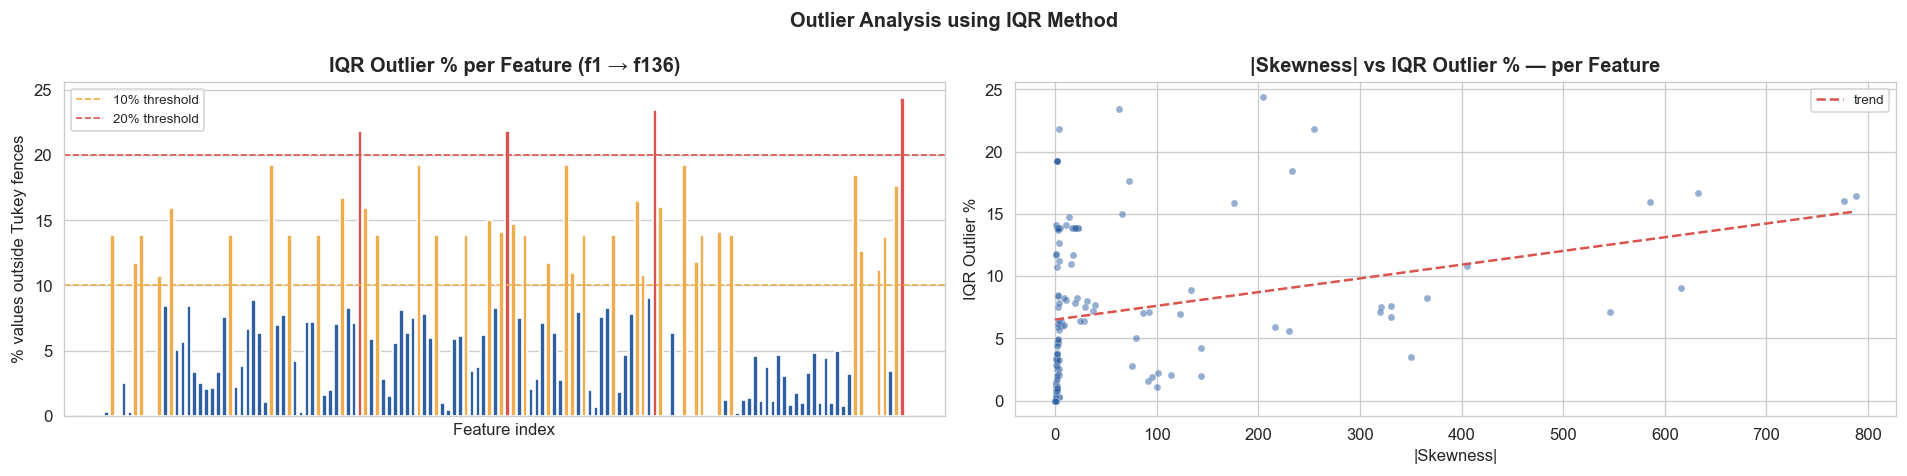

Key insight: higher skewness -> more IQR outliers. This confirms the two are related.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Outlier Analysis using IQR Method', fontsize=12, fontweight='bold')

# Left: outlier % per feature (sorted by index f1 -> f136)
vals = outlier_series.reindex(feat_cols).values
colors_out = ['#D9534F' if v > 20 else '#F0AD4E' if v > 10 else '#2E5FA3' for v in vals]
axes[0].bar(range(len(vals)), vals, color=colors_out, width=0.8)
axes[0].axhline(10, color='#F0AD4E', linestyle='--', lw=1, label='10% threshold')
axes[0].axhline(20, color='#D9534F', linestyle='--', lw=1, label='20% threshold')
axes[0].set_title('IQR Outlier % per Feature (f1 → f136)', fontweight='bold')
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('% values outside Tukey fences')
axes[0].set_xticks([])
axes[0].legend(fontsize=8)

# Right: scatter — skewness vs outlier %
# Shows the relationship between how skewed a feature is and how many outliers it has
skew_vals    = skew_series.reindex(feat_cols).values
outlier_vals = outlier_series.reindex(feat_cols).values
axes[1].scatter(np.abs(skew_vals), outlier_vals,
                alpha=0.5, s=18, color='#2E5FA3', edgecolors='white', lw=0.3)
axes[1].set_title('|Skewness| vs IQR Outlier % — per Feature', fontweight='bold')
axes[1].set_xlabel('|Skewness|')
axes[1].set_ylabel('IQR Outlier %')
# Fit a trend line
mask = ~np.isnan(skew_vals) & ~np.isnan(outlier_vals)
z = np.polyfit(np.abs(skew_vals[mask]), outlier_vals[mask], 1)
xline = np.linspace(0, np.abs(skew_vals).max(), 100)
axes[1].plot(xline, np.polyval(z, xline), color='#D9534F', lw=1.5, linestyle='--',
             label='trend')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plots/01_outlier_iqr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: higher skewness -> more IQR outliers. This confirms the two are related.')

### Zone Analysis (body vs anchor vs title vs URL vs whole doc)

> Most features come in groups of 5 — one per document zone.
> Zone = where in the document the feature is computed.
> For example, BM25(title) and BM25(body) are separate features.
> This analysis is to find out which zone carries the most signal.

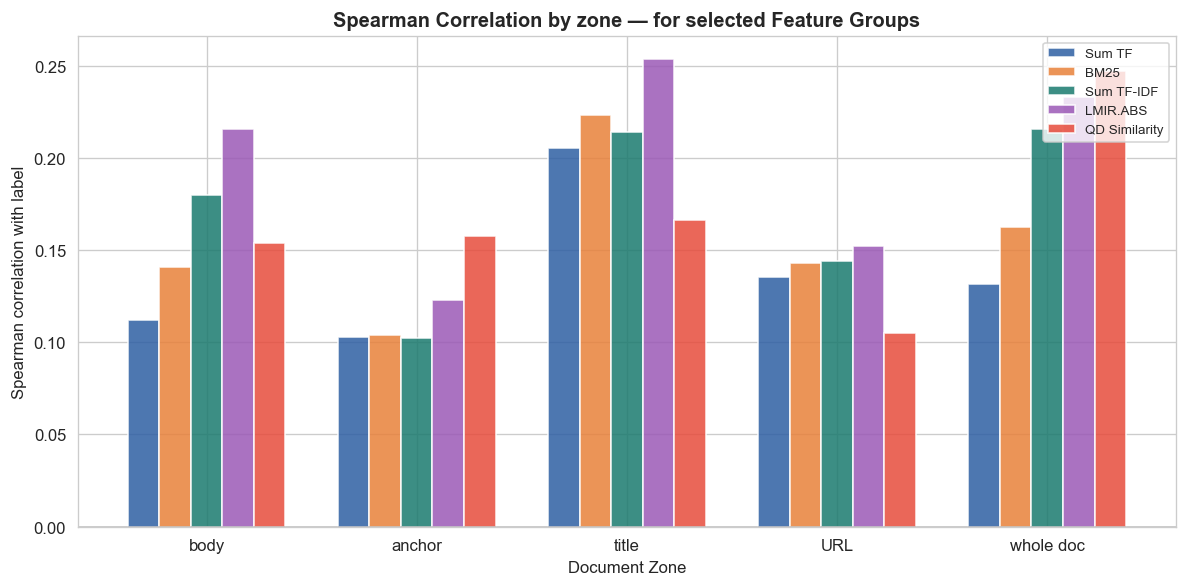

Insights:
- Title and whole-doc zones tend to carry strongest signal for BM25.
- Whole-doc zones are carrying more signal for most features, but not for all (Ex: Sum TF).
- Two or more zones can have similar correlation for multiple feature groups.
- Anchor text is highly informative for query-doc similarity.


In [41]:
# Each group of 5 features = [body, anchor, title, URL, whole doc]
zone_names = ['body', 'anchor', 'title', 'URL', 'whole doc']

five_zone_groups = {
    'Sum TF':       list(range(21, 26)),
    'BM25':         list(range(71, 76)),
    'Sum TF-IDF':   list(range(46, 51)),
    'LMIR.ABS':     list(range(76, 81)),
    'QD Similarity':list(range(99, 104)),
}

zone_corr = {}
for group, feat_indices in five_zone_groups.items():
    feats = [f'f{i}' for i in feat_indices]
    zone_corr[group] = [corr_series.get(f, 0) for f in feats]

zone_df = pd.DataFrame(zone_corr, index=zone_names).T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(zone_names))
width = 0.15
colors = ['#2E5FA3', '#E8813A', '#1A7A6E', '#9B59B6', '#E74C3C']
for i, (group, row) in enumerate(zone_df.iterrows()):
    ax.bar(x + i*width, row.values, width, label=group, color=colors[i], alpha=0.85)

ax.set_title('Spearman Correlation by zone — for selected Feature Groups',
             fontweight='bold')
ax.set_xlabel('Document Zone')
ax.set_ylabel('Spearman correlation with label')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(zone_names)
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('outputs/plots/01_zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insights:\n- Title and whole-doc zones tend to carry strongest signal for BM25.')
print('- Whole-doc zones are carrying more signal for most features, but not for all (Ex: Sum TF).')
print('- Two or more zones can have similar correlation for multiple feature groups.')
print('- Anchor text is highly informative for query-doc similarity.')

### EDA Summary

In [42]:
print("""
EDA SUMMARY:

Label Distribution
  - Label=0 (irrelevant) makes up ~52% of all pairs
  - Only ~2.5% of docs are label=3 or label=4 (highly/perfectly relevant)
  - Accuracy will not be a helpful metric for evaluation. Will use NDGC@10, MAP, MRR.

Query Analysis
  - ~3% of queries have zero relevant documents (impossible to rank)
  - Docs per query: mean=120, median=110, max=809

Features & Outliers
  - Feature values range from -2B to +980M. Normalisation is critical prior to modeling.
  - Most features have some outliers (> 3*std)

Most Informative Features
  - TF-IDF and BM25 features have highest spearman correlation with label
  - PageRank, Inlink count, QualityScore provide weaker but complementary signal
  - Title zone tends to be most informative for text matching features

Feature Correlations
  - TF, TF-IDF, and BM25 features are highly inter-correlated
  - PageRank / Quality / URL features are more independent
""")


EDA SUMMARY:

Label Distribution
  - Label=0 (irrelevant) makes up ~52% of all pairs
  - Only ~2.5% of docs are label=3 or label=4 (highly/perfectly relevant)
  - Accuracy will not be a helpful metric for evaluation. Will use NDGC@10, MAP, MRR.

Query Analysis
  - ~3% of queries have zero relevant documents (impossible to rank)
  - Docs per query: mean=120, median=110, max=809

Features & Outliers
  - Feature values range from -2B to +980M. Normalisation is critical prior to modeling.
  - Most features have some outliers (> 3*std)

Most Informative Features
  - TF-IDF and BM25 features have highest spearman correlation with label
  - PageRank, Inlink count, QualityScore provide weaker but complementary signal
  - Title zone tends to be most informative for text matching features

Feature Correlations
  - TF, TF-IDF, and BM25 features are highly inter-correlated
  - PageRank / Quality / URL features are more independent



In [43]:
# Saving correlation data for use in downstream notebooks
corr_series.to_csv('data/processed/feature_label_correlations.csv', header=['spearman_corr'])
print('Saved: data/processed/feature_label_correlations.csv')

Saved: data/processed/feature_label_correlations.csv
